In [1]:
%load_ext jupyter_tikz
%load_ext watermark


In [2]:
import matplotlib as mpl
import re
import xml.etree.ElementTree as xml_etree


import dendropy as dp
from IPython.display import display, HTML
from hstrat import _auxiliary_lib as hstrat_aux
from matplotlib import pyplot as plt
import polars as pl
from slugify import slugify
import svgpath2mpl
from teeplot import teeplot as tp

from pylib._seed_global_rngs import seed_global_rngs


Covasim 3.1.6 (2024-01-28) — © 2020-2024 by IDM


In [3]:
%watermark -diwmuv -iv


Last updated: 2025-06-04T03:16:01.180602+00:00

Python implementation: CPython
Python version       : 3.10.12
IPython version      : 7.31.1

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.8.0-1029-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit

hstrat     : 1.20.11
re         : 2.2.1
matplotlib : 3.9.2
svgpath2mpl: 1.0.0
dendropy   : 5.0.7
teeplot    : 1.4.2
polars     : 1.29.0

Watermark: 2.4.3



In [4]:
teeplot_subdir = "2025-06-03-vanilla-treeviz-dendropy"
teeplot_subdir


'2025-06-03-vanilla-treeviz-dendropy'

In [5]:
seed_global_rngs(1)


## Get Data


In [6]:
url = "https://osf.io/r8skg/download"
tmp_path = f"/tmp/{teeplot_subdir}.pqt"

print(f"Downloading data from {url}")

pl.scan_parquet(
    url,
    low_memory=True,
    retries=5,
).sink_parquet(tmp_path)
print("done!")


done!


In [7]:
df = pl.scan_parquet(
    tmp_path,
    low_memory=True,
    retries=5,
)
schema = df.collect_schema()


In [8]:
fil = (
    df.filter(
        pl.col("trt_hsurf_bits").eq(0),
    )
    .filter(
        pl.col("replicate_uuid").eq(
            pl.col("replicate_uuid").first().over("trt_name"),
        )
    )
    .select(
        pl.exclude([k for k, v in schema.items() if v == pl.String]),
    )
    .collect()
)


## Plot Data


670
teeplots/trt_name=sben1-1x-gdel1-1x+viz=display-tikz-plot+ext=.pdf
teeplots/trt_name=sben1-1x-gdel1-1x+viz=display-tikz-plot+ext=.png


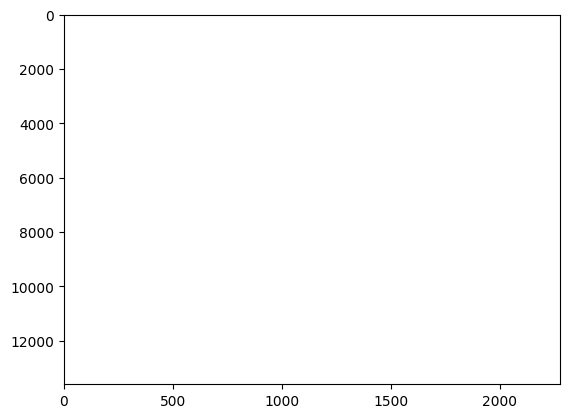

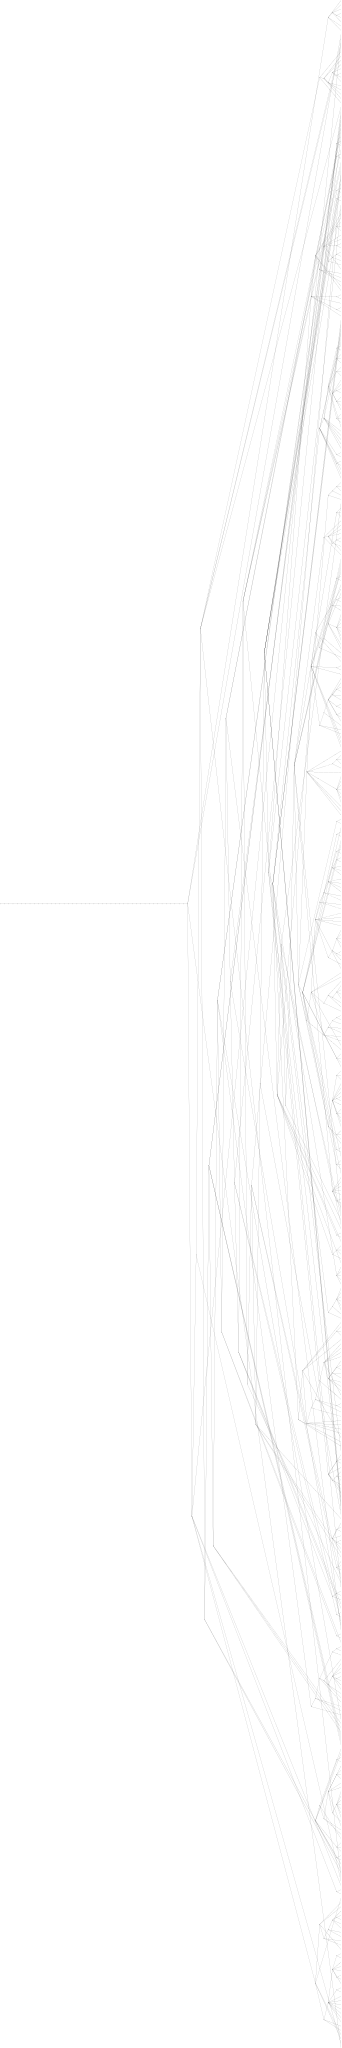

712
teeplots/trt_name=sben1-3x-gneu+viz=display-tikz-plot+ext=.pdf
teeplots/trt_name=sben1-3x-gneu+viz=display-tikz-plot+ext=.png


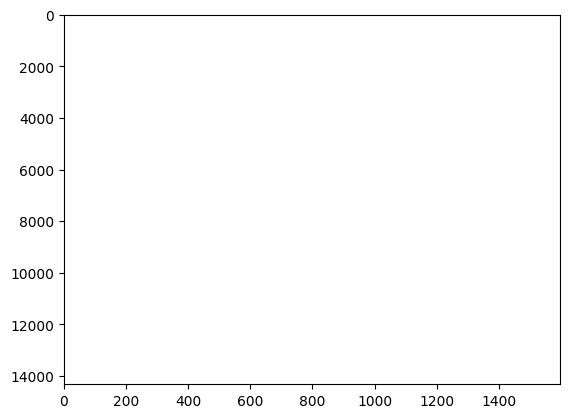

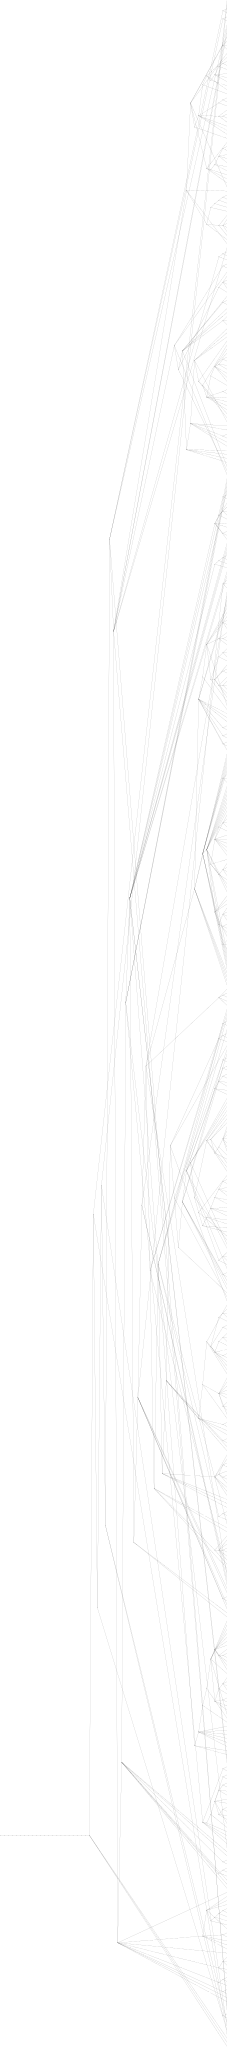

572
teeplots/trt_name=sben2x-gdel2x+viz=display-tikz-plot+ext=.pdf
teeplots/trt_name=sben2x-gdel2x+viz=display-tikz-plot+ext=.png


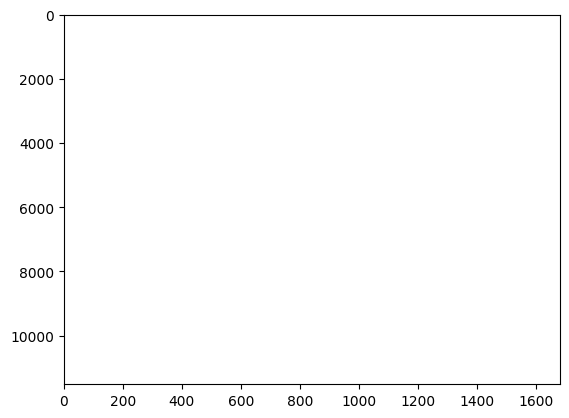

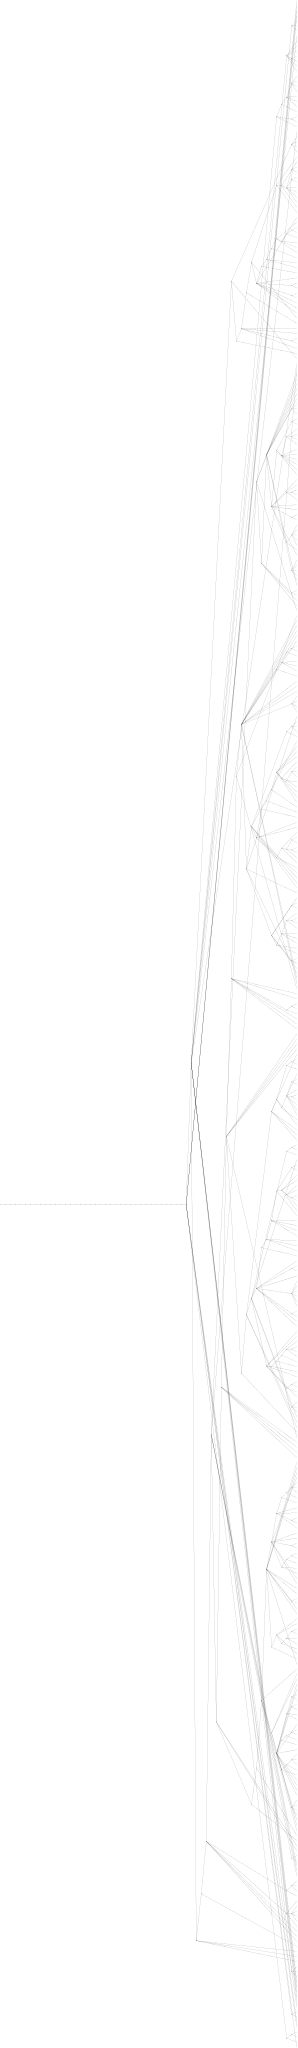

590
teeplots/trt_name=sneu-gneu+viz=display-tikz-plot+ext=.pdf
teeplots/trt_name=sneu-gneu+viz=display-tikz-plot+ext=.png


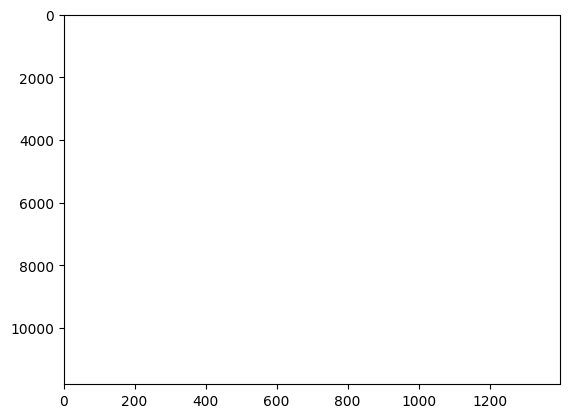

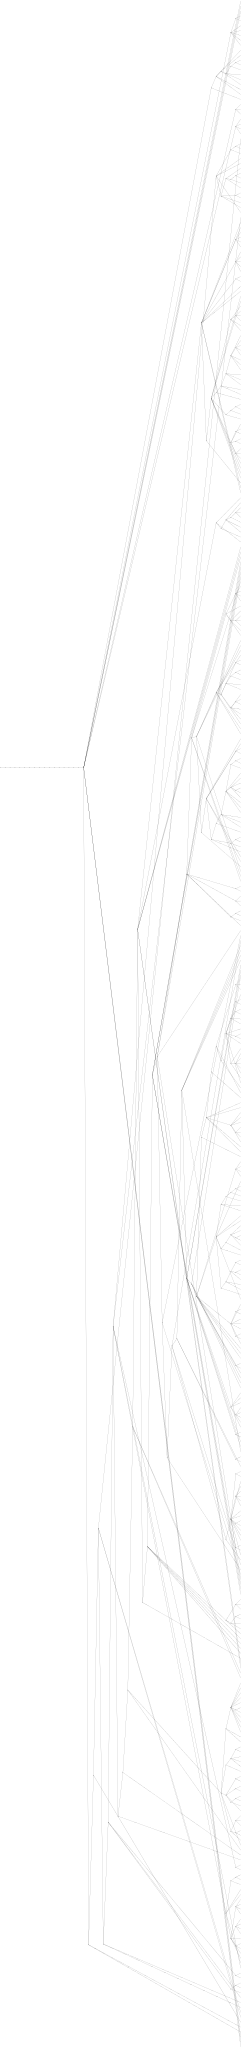

591
teeplots/trt_name=sben1-3x-gdel1-3x+viz=display-tikz-plot+ext=.pdf
teeplots/trt_name=sben1-3x-gdel1-3x+viz=display-tikz-plot+ext=.png


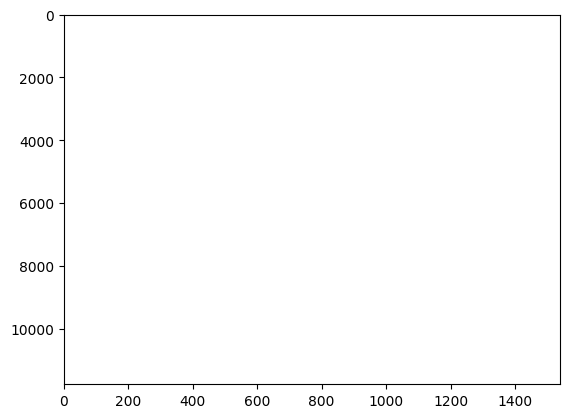

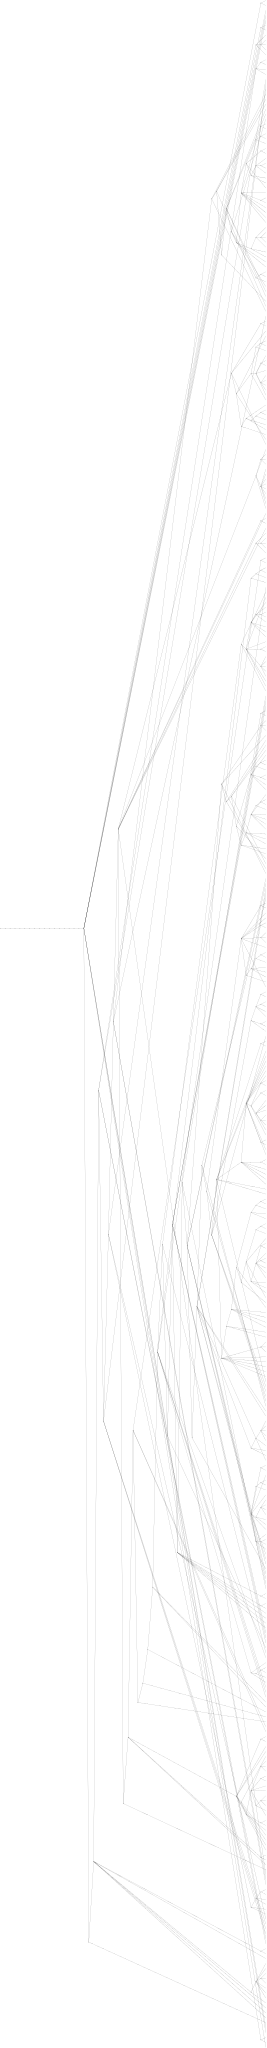

653
teeplots/trt_name=sben1-1x-gneu+viz=display-tikz-plot+ext=.pdf
teeplots/trt_name=sben1-1x-gneu+viz=display-tikz-plot+ext=.png


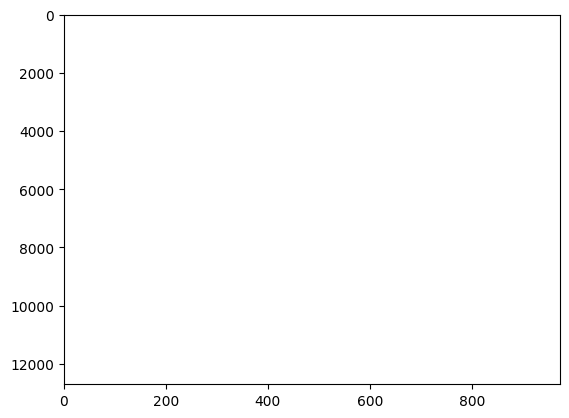

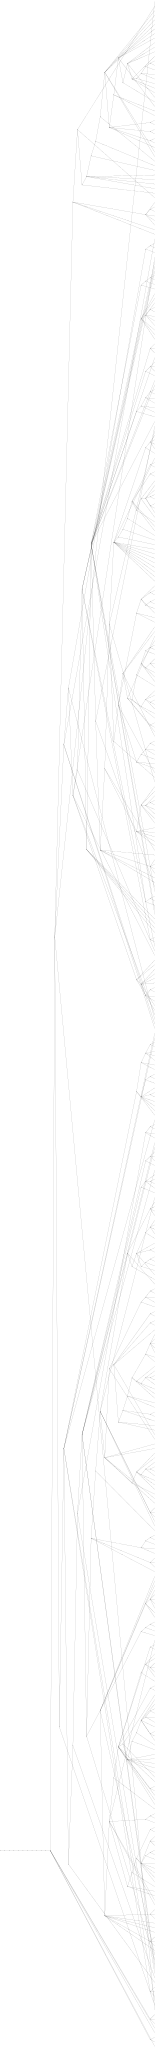

680
teeplots/trt_name=sben2x-gneu+viz=display-tikz-plot+ext=.pdf
teeplots/trt_name=sben2x-gneu+viz=display-tikz-plot+ext=.png


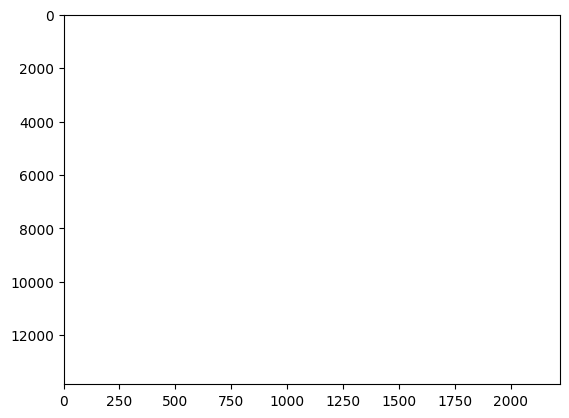

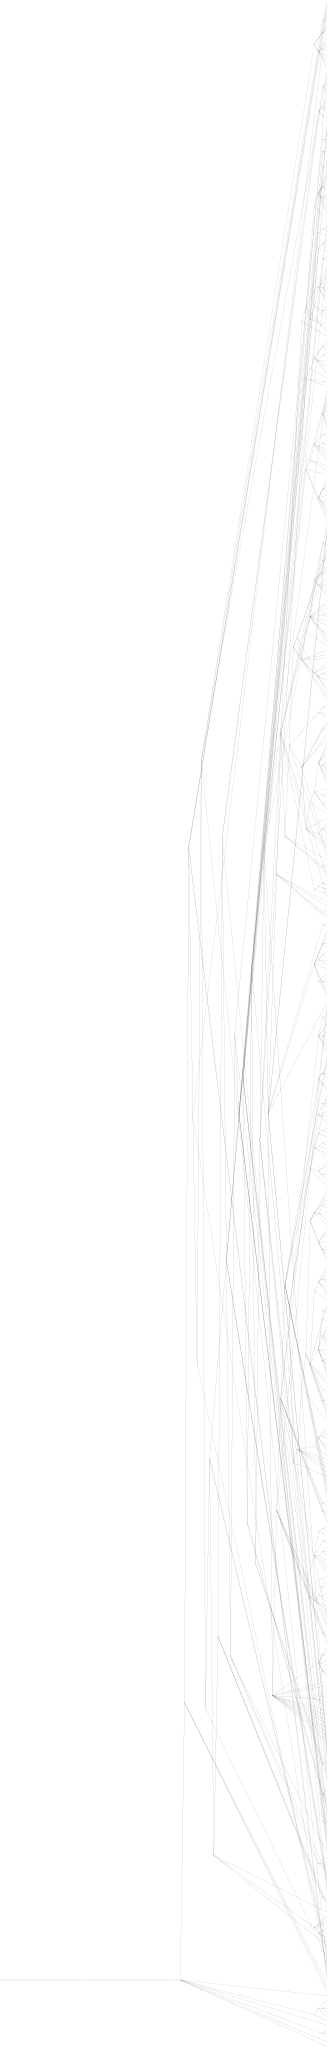

In [9]:
for (trt_name,), group in fil.group_by("trt_name"):
    display(HTML(f"<h1>{trt_name}</h1>"))

    phylo_df = group.to_pandas()

    phylo_df = hstrat_aux.alifestd_mark_num_descendants_asexual(phylo_df)
    phylo_df = hstrat_aux.alifestd_mark_clade_duration_asexual(phylo_df)
    phylo_df[
        "calc_clade_trait_count_asexual"
    ] = hstrat_aux.alifestd_calc_clade_trait_count_asexual(
        phylo_df, trait_mask=phylo_df["is_focal_defmut"].values
    )

    mask = (
        (phylo_df["origin_time"] > 50)
        & (phylo_df["num_descendants"] >= 500)
        & (phylo_df["num_descendants"] <= 750)
        & (phylo_df["calc_clade_trait_count_asexual"] > 0)
    )
    sample_idx = phylo_df.loc[mask, "id"].sample(n=1, random_state=1).item()
    sample_mask = phylo_df["id"] == sample_idx

    phylo_df = hstrat_aux.alifestd_mask_descendants_asexual(
        phylo_df,
        ancestor_mask=phylo_df["is_focal_defmut"],
    ).rename(
        columns={
            "alifestd_mask_descendants_asexual": "focal_defmut_descendant",
        },
    )

    phylo_df = hstrat_aux.alifestd_mask_descendants_asexual(
        phylo_df,
        ancestor_mask=sample_mask,
    )

    phylo_df["extant"] = phylo_df["alifestd_mask_descendants_asexual"]
    print(phylo_df["extant"].sum())
    phylo_df = hstrat_aux.alifestd_prune_extinct_lineages_asexual(phylo_df)

    sample_ot_min = phylo_df.loc[
        phylo_df["extant"].values, "origin_time"
    ].min()
    sample_ot_max = phylo_df.loc[
        phylo_df["extant"].values, "origin_time"
    ].max()

    newick = hstrat_aux.alifestd_as_newick_asexual(
        phylo_df,
        taxon_label="focal_defmut_descendant",
    )

    tree = dp.Tree.get(
        data=newick,
        schema="newick",
        suppress_internal_node_taxa=True,
        suppress_leaf_node_taxa=True,
    )

    # way 1, via matplotlib
    with tp.teed(
        dp.Tree.display_tikz_plot,
        tree,
        node_label_compose_fn=lambda n: "",
        teeplot_outattrs={"trt_name": slugify(trt_name)},
    ) as tikz_svg:
        # adapted from https://nbviewer.org/github/nvictus/svgpath2mpl/blob/master/examples/homer.ipynb
        root = xml_etree.fromstring(
            tikz_svg.data.replace("rgb(0%, 0%, 0%)", "black")
        )
        width = int(re.match(r"\d+", root.attrib["width"]).group())
        height = int(re.match(r"\d+", root.attrib["height"]).group())
        path_elems = root.findall(".//{http://www.w3.org/2000/svg}path")

        paths = [
            svgpath2mpl.parse_path(elem.attrib["d"]) for elem in path_elems
        ]
        edgecolors = [elem.attrib.get("stroke", "none") for elem in path_elems]
        facecolors = [elem.attrib.get("fill", "none") for elem in path_elems]
        linewidths = [
            elem.attrib.get("stroke_width", 1) for elem in path_elems
        ]
        collection = mpl.collections.PathCollection(
            paths,
            edgecolors=edgecolors,
            facecolors=facecolors,
            linewidths=linewidths,
        )

        ax = plt.gca()
        collection.set_transform(ax.transData)
        ax.add_artist(collection)
        ax.set_xlim([0, width])
        ax.set_ylim([height, 0])

    # way 2, pure svg
    tikz_svg = tree.display_tikz_plot(node_label_compose_fn=lambda n: "")
    tikz_svg.data = tikz_svg.data.replace(
        "<svg",
        "<svg style='background-color: white'",
    )
    display(tikz_svg)
